# God‑Mod Seasonality Analysis for Day Trading

This notebook is designed to boost your day‑trading edge by providing an advanced, multi‑timeframe seasonality analysis for the following assets:

- Dow Jones (^DJI)
- Nasdaq (^IXIC)
- S&P 500 (^GSPC)
- Gold (GC=F)
- Silver (SI=F)
- Brent Crude (BZ=F)
- DAX (^GDAXI)

We perform:

**Intraday Analysis (1‑month of 60‑minute data):**
- Compute returns, grouped by hour and day‑of‑week with advanced statistics.
- Plot bar charts (with error bars) and a heatmap.
- Perform Fourier analysis (FFT) to uncover dominant cyclical frequencies.

**Daily Seasonality Analysis (5‑year daily data):**
- Compute daily returns, grouped by month and day‑of‑week.
- Use seasonal decomposition (STL) and heatmaps to reveal seasonal patterns.

Finally, a summary function prints detailed results for each asset.

In [18]:
# %%
import warnings
warnings.filterwarnings('ignore')

import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from datetime import datetime

# For seasonal decomposition
from statsmodels.tsa.seasonal import STL
from scipy.fft import fft, fftfreq
from sklearn.cluster import KMeans

# Configure logging and seaborn style for professional plots
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
sns.set_theme(style="whitegrid", context="talk")

## 1. Data Download Functions

We define two functions:

- `download_intraday_data`: Downloads intraday (60‑minute) data (maximum period allowed is 1mo).
- `download_daily_data`: Downloads daily data for a longer period (e.g. 5y).


In [19]:
# %%
def download_intraday_data(ticker: str, period: str = "1mo", interval: str = "60m") -> pd.DataFrame:
    """
    Download intraday data (60m interval) using yfinance.
    """
    logging.info(f"Downloading intraday data for {ticker}: period={period}, interval={interval}")
    df = yf.download(ticker, period=period, interval=interval, progress=False)
    if df.empty:
        logging.warning(f"No intraday data for {ticker}.")
    else:
        df.dropna(inplace=True)
    return df

def download_daily_data(ticker: str, period: str = "5y") -> pd.DataFrame:
    """
    Download daily historical data for a longer period.
    """
    logging.info(f"Downloading daily data for {ticker}: period={period}")
    df = yf.download(ticker, period=period, progress=False)
    if df.empty:
        logging.warning(f"No daily data for {ticker}.")
    else:
        df.dropna(inplace=True)
    return df

## 2. Advanced Intraday Analysis

We compute intraday returns (using the adjusted close) and add columns for Hour and DayOfWeek.
We then calculate advanced statistics (mean, median, std, skewness, kurtosis) by hour and day-of-week.


In [20]:
# %%
def compute_intraday_returns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute intraday returns and add 'Hour' and 'DayOfWeek' columns.
    """
    df = df.copy()
    df['Return'] = df['Adj Close'].pct_change()
    df.dropna(inplace=True)
    df['Hour'] = df.index.hour
    df['DayOfWeek'] = df.index.dayofweek  # Monday=0, ..., Friday=4
    return df

def advanced_intraday_stats(df: pd.DataFrame):
    """
    Compute advanced statistics (mean, median, std, skew, kurtosis) by Hour and DayOfWeek.
    """
    from scipy.stats import skew, kurtosis
    
    # Group by Hour
    hourly = df.groupby('Hour')['Return'].agg(['mean', 'median', 'std', 'count'])
    hourly['skew'] = df.groupby('Hour')['Return'].apply(skew)
    hourly['kurtosis'] = df.groupby('Hour')['Return'].apply(kurtosis)
    
    # Group by DayOfWeek
    dow = df.groupby('DayOfWeek')['Return'].agg(['mean', 'median', 'std', 'count'])
    dow['skew'] = df.groupby('DayOfWeek')['Return'].apply(skew)
    dow['kurtosis'] = df.groupby('DayOfWeek')['Return'].apply(kurtosis)
    
    return hourly.reset_index(), dow.reset_index()


## 3. Intraday Plots and Fourier Analysis

We create well-designed plots for intraday patterns and use a Fast Fourier Transform (FFT) to detect cyclical frequencies in hourly returns.


In [21]:
# %%
def plot_intraday_patterns(hourly_stats: pd.DataFrame, dow_stats: pd.DataFrame, asset_name: str):
    """
    Plot intraday patterns: hourly average return (with error bars) and day-of-week averages.
    """
    plt.figure(figsize=(16,6))
    
    # Hourly average returns with error bars (std)
    plt.subplot(1,2,1)
    sns.barplot(x='Hour', y='mean', data=hourly_stats, palette="viridis", edgecolor='black', ci=None)
    plt.errorbar(hourly_stats['Hour'], hourly_stats['mean'], yerr=hourly_stats['std'], fmt='none', c='black', capsize=5)
    plt.title(f"{asset_name} - Hourly Average Returns")
    plt.xlabel("Hour of Day")
    plt.ylabel("Average Return")
    
    # Day-of-week average returns
    dow_mapping = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}
    dow_stats['Day'] = dow_stats['DayOfWeek'].map(dow_mapping)
    plt.subplot(1,2,2)
    sns.barplot(x='Day', y='mean', data=dow_stats[dow_stats['DayOfWeek'] < 5], palette="rocket", edgecolor='black')
    plt.title(f"{asset_name} - Day-of-Week Average Returns")
    plt.xlabel("Day of Week")
    plt.ylabel("Average Return")
    
    plt.tight_layout()
    plt.show()

def fft_analysis(df: pd.DataFrame, asset_name: str):
    """
    Perform FFT on hourly aggregated returns and plot the amplitude spectrum.
    """
    # Aggregate returns by hour (averaged over days)
    hourly_series = df.groupby(df.index.hour)['Return'].mean()
    N = len(hourly_series)
    yf_fft = fft(hourly_series - hourly_series.mean())  # remove mean
    xf = fftfreq(N, d=1)[:N//2]
    
    plt.figure(figsize=(10,6))
    # Removed 'use_line_collection=True' to avoid the TypeError
    plt.stem(xf, 2.0/N * np.abs(yf_fft[:N//2]))
    plt.title(f"{asset_name} - FFT Amplitude Spectrum of Hourly Returns")
    plt.xlabel("Frequency (cycles per hour)")
    plt.ylabel("Amplitude")
    plt.show()


## 4. Advanced Daily Seasonality Analysis

We now download daily data (over 5 years), compute daily returns, and analyze seasonality by month and day-of-week.
We also apply STL decomposition to the monthly aggregated return series.


In [22]:
# %%
def compute_daily_returns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute daily returns and add 'Month' and 'DayOfWeek' columns.
    """
    df = df.copy()
    df['Return'] = df['Adj Close'].pct_change()
    df.dropna(inplace=True)
    df['Month'] = df.index.month
    df['DayOfWeek'] = df.index.dayofweek
    return df

def daily_seasonality_stats(df: pd.DataFrame):
    """
    Compute daily return statistics by Month and DayOfWeek.
    """
    monthly_stats = df.groupby('Month')['Return'].agg(['mean', 'std', 'count']).reset_index()
    dow_stats = df.groupby('DayOfWeek')['Return'].agg(['mean', 'std', 'count']).reset_index()
    return monthly_stats, dow_stats

def plot_daily_seasonality(monthly_stats: pd.DataFrame, dow_stats: pd.DataFrame, asset_name: str):
    """
    Plot daily seasonality: monthly and day-of-week heatmaps.
    """
    plt.figure(figsize=(14,6))
    
    # Monthly seasonality bar chart
    plt.subplot(1,2,1)
    sns.barplot(x='Month', y='mean', data=monthly_stats, palette="coolwarm", edgecolor='black')
    plt.title(f"{asset_name} - Average Daily Returns by Month")
    plt.xlabel("Month")
    plt.ylabel("Average Return")
    
    # Day-of-week seasonality bar chart
    dow_mapping = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}
    dow_stats['Day'] = dow_stats['DayOfWeek'].map(dow_mapping)
    plt.subplot(1,2,2)
    sns.barplot(x='Day', y='mean', data=dow_stats, palette="magma", edgecolor='black')
    plt.title(f"{asset_name} - Average Daily Returns by Day of Week")
    plt.xlabel("Day of Week")
    plt.ylabel("Average Return")
    
    plt.tight_layout()
    plt.show()

def stl_decomposition(df: pd.DataFrame, asset_name: str):
    """
    Apply STL decomposition on monthly aggregated daily returns.
    """
    monthly_prices = df['Adj Close'].resample('M').last()
    monthly_returns = monthly_prices.pct_change().dropna()
    # Create a pandas Series with a DateTimeIndex (frequency monthly)
    monthly_returns.index = pd.DatetimeIndex(monthly_returns.index).to_period('M').to_timestamp()
    
    stl = STL(monthly_returns, period=12)
    res = stl.fit()
    
    plt.figure(figsize=(12,8))
    res.plot()
    plt.suptitle(f"{asset_name} - STL Decomposition of Monthly Returns", fontsize=16)
    plt.tight_layout()
    plt.show()


## 5. Detailed Summary (Cheat Sheet) Explanation

This function prints a comprehensive summary of the advanced analysis for each asset.


In [23]:
# %%
def explain_results(asset_name: str, hourly_stats: pd.DataFrame, dow_intraday: pd.DataFrame,
                    monthly_stats: pd.DataFrame, dow_daily: pd.DataFrame, fft_freqs: np.ndarray, fft_amp: np.ndarray):
    # Intraday Best/Worst Hours
    best_hour = hourly_stats.loc[hourly_stats['mean'].idxmax()]
    worst_hour = hourly_stats.loc[hourly_stats['mean'].idxmin()]
    
    # Intraday Day-of-Week
    dow_mapping = {0:'Monday',1:'Tuesday',2:'Wednesday',3:'Thursday',4:'Friday',5:'Saturday',6:'Sunday'}
    best_dow_intraday = dow_intraday.loc[dow_intraday['mean'].idxmax()]
    worst_dow_intraday = dow_intraday.loc[dow_intraday['mean'].idxmin()]
    
    # Daily Seasonality
    best_month = monthly_stats.loc[monthly_stats['mean'].idxmax()]
    worst_month = monthly_stats.loc[monthly_stats['mean'].idxmin()]
    best_dow_daily = dow_daily.loc[dow_daily['mean'].idxmax()]
    worst_dow_daily = dow_daily.loc[dow_daily['mean'].idxmin()]
    
    print(f"\n{'='*70}\nAnalysis Summary for {asset_name}\n{'='*70}")
    print(f"Intraday Hourly Analysis:")
    print(f"  • Best Hour: {int(best_hour['Hour'])} (Avg Return: {best_hour['mean']*100:.2f}%)")
    print(f"  • Worst Hour: {int(worst_hour['Hour'])} (Avg Return: {worst_hour['mean']*100:.2f}%)")
    
    print(f"\nIntraday Day-of-Week Analysis:")
    print(f"  • Best Day: {dow_mapping[best_dow_intraday['DayOfWeek']]} (Avg Return: {best_dow_intraday['mean']*100:.2f}%)")
    print(f"  • Worst Day: {dow_mapping[worst_dow_intraday['DayOfWeek']]} (Avg Return: {worst_dow_intraday['mean']*100:.2f}%)")
    
    print(f"\nDaily Seasonality Analysis:")
    print(f"  • Best Month: {int(best_month['Month'])} (Avg Daily Return: {best_month['mean']*100:.2f}%)")
    print(f"  • Worst Month: {int(worst_month['Month'])} (Avg Daily Return: {worst_month['mean']*100:.2f}%)")
    print(f"  • Best Day (Daily): {dow_mapping[best_dow_daily['DayOfWeek']]} (Avg Return: {best_dow_daily['mean']*100:.2f}%)")
    print(f"  • Worst Day (Daily): {dow_mapping[worst_dow_daily['DayOfWeek']]} (Avg Return: {worst_dow_daily['mean']*100:.2f}%)")
    
    # FFT dominant frequency
    dominant_idx = np.argmax(fft_amp)
    dominant_freq = fft_freqs[dominant_idx]
    print(f"\nFFT Analysis:")
    print(f"  • Dominant frequency: {dominant_freq:.3f} cycles per hour")
    
    explanation = f"""
    {asset_name} Seasonality Cheat Sheet:
      - **Intraday Patterns:** The best trading hour is around {int(best_hour['Hour'])}, while the worst is around {int(worst_hour['Hour'])}. 
        The best intraday day is {dow_mapping[best_dow_intraday['DayOfWeek']]}, and the worst is {dow_mapping[worst_dow_intraday['DayOfWeek']]}.
      - **Daily Patterns:** On a daily basis, month {int(best_month['Month'])} tends to be most favorable, while month {int(worst_month['Month'])} is the least.
        Similarly, {dow_mapping[best_dow_daily['DayOfWeek']]} shows the best daily performance, and {dow_mapping[worst_dow_daily['DayOfWeek']]} the worst.
      - **Cyclical Behavior:** FFT analysis reveals a dominant cycle of {dominant_freq:.3f} cycles per hour.
    
    Use these insights to fine‑tune your day‑trading strategy by focusing on high‑probability timeframes and managing risk during less favorable periods.
    """
    print(explanation)

## 6. Main Analysis Loop for All Assets

For each asset, we run the advanced intraday and daily analyses, plot the outputs, and print the summary.


2025-02-13 01:37:56,368 - INFO - 
=== Processing Dow Jones (^DJI) ===
2025-02-13 01:37:56,369 - INFO - Downloading intraday data for ^DJI: period=1mo, interval=60m
2025-02-13 01:37:56,956 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 01:37:56,969 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 01:37:57,080 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 01:37:57,088 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numb

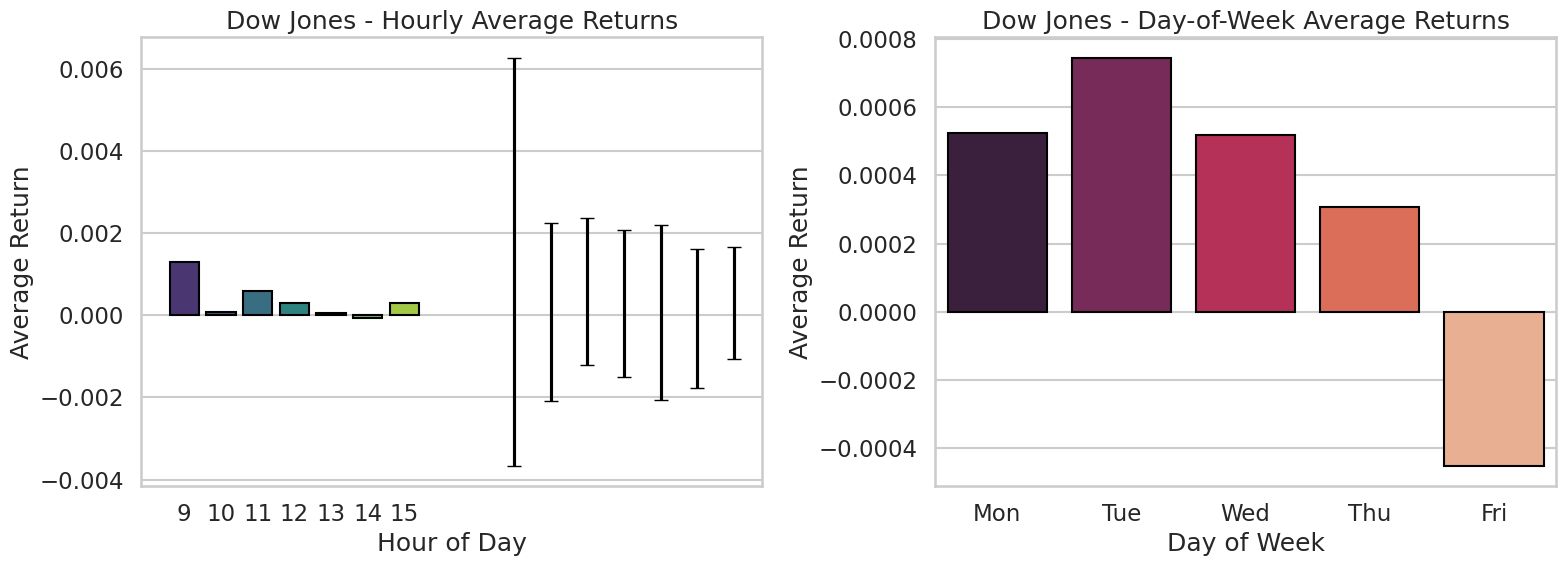

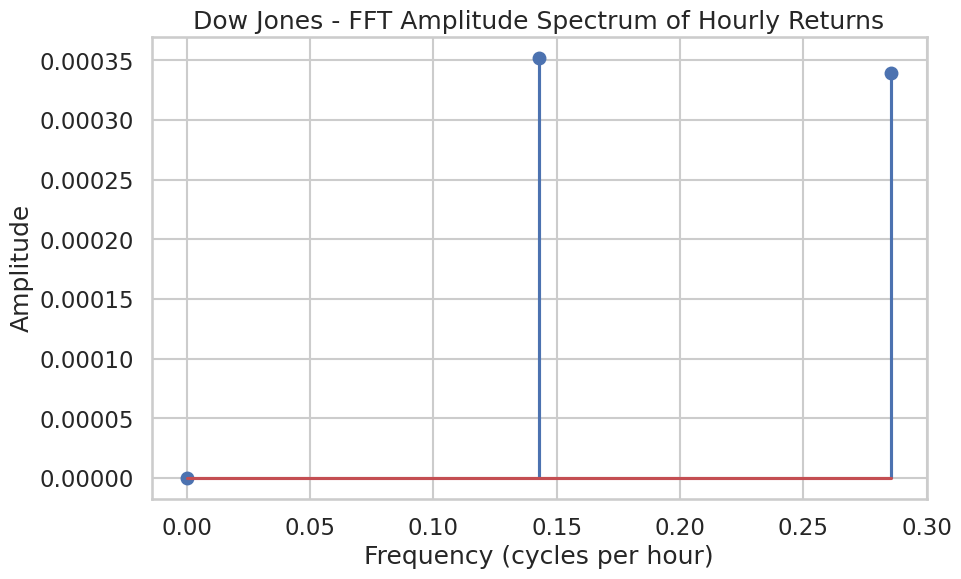

2025-02-13 01:37:57,781 - INFO - Downloading daily data for ^DJI: period=5y
2025-02-13 01:37:58,115 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 01:37:58,124 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 01:37:58,248 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 01:37:58,256 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


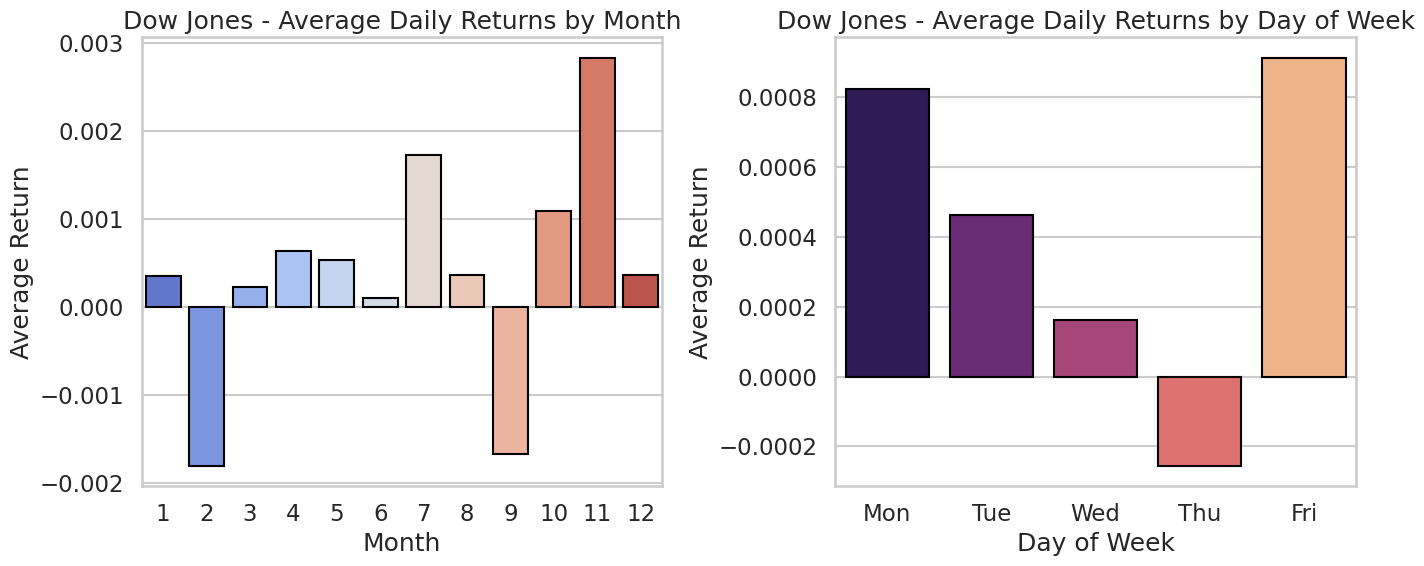

<Figure size 1200x800 with 0 Axes>

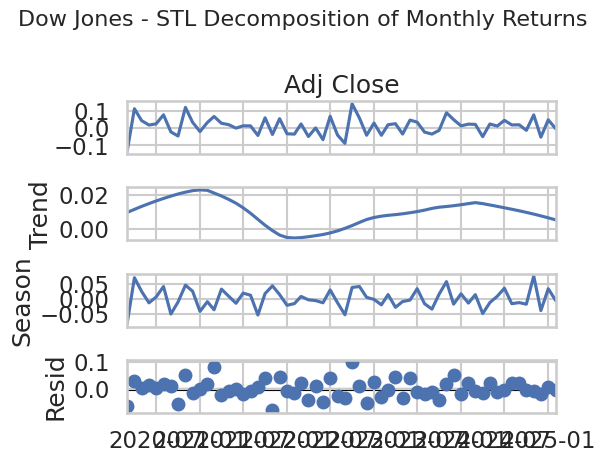

2025-02-13 01:38:00,388 - INFO - 
=== Processing Nasdaq (^IXIC) ===
2025-02-13 01:38:00,388 - INFO - Downloading intraday data for ^IXIC: period=1mo, interval=60m
2025-02-13 01:38:00,565 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 01:38:00,575 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.



Analysis Summary for Dow Jones
Intraday Hourly Analysis:
  • Best Hour: 9 (Avg Return: 0.13%)
  • Worst Hour: 14 (Avg Return: -0.01%)

Intraday Day-of-Week Analysis:
  • Best Day: Tuesday (Avg Return: 0.07%)
  • Worst Day: Friday (Avg Return: -0.05%)

Daily Seasonality Analysis:
  • Best Month: 11 (Avg Daily Return: 0.28%)
  • Worst Month: 2 (Avg Daily Return: -0.18%)
  • Best Day (Daily): Friday (Avg Return: 0.09%)
  • Worst Day (Daily): Thursday (Avg Return: -0.03%)

FFT Analysis:
  • Dominant frequency: 0.143 cycles per hour

    Dow Jones Seasonality Cheat Sheet:
      - **Intraday Patterns:** The best trading hour is around 9, while the worst is around 14. 
        The best intraday day is Tuesday, and the worst is Friday.
      - **Daily Patterns:** On a daily basis, month 11 tends to be most favorable, while month 2 is the least.
        Similarly, Friday shows the best daily performance, and Thursday the worst.
      - **Cyclical Behavior:** FFT analysis reveals a dominant cyc

2025-02-13 01:38:00,694 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 01:38:00,704 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


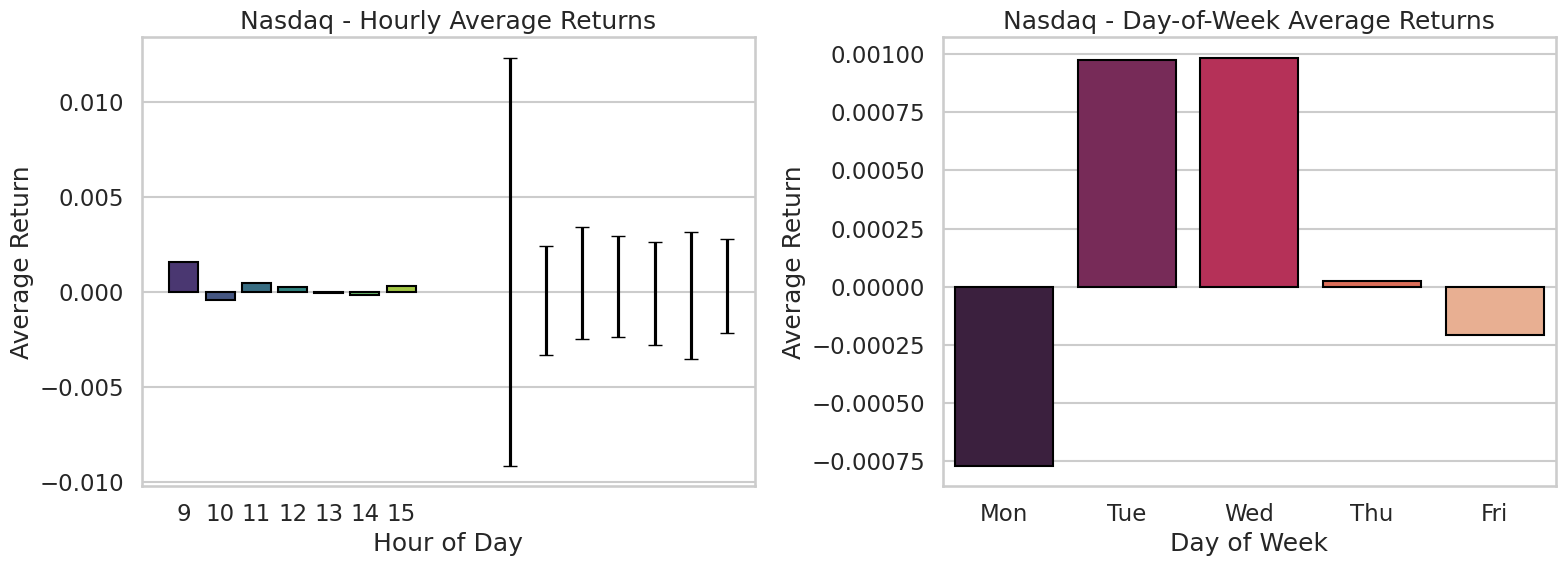

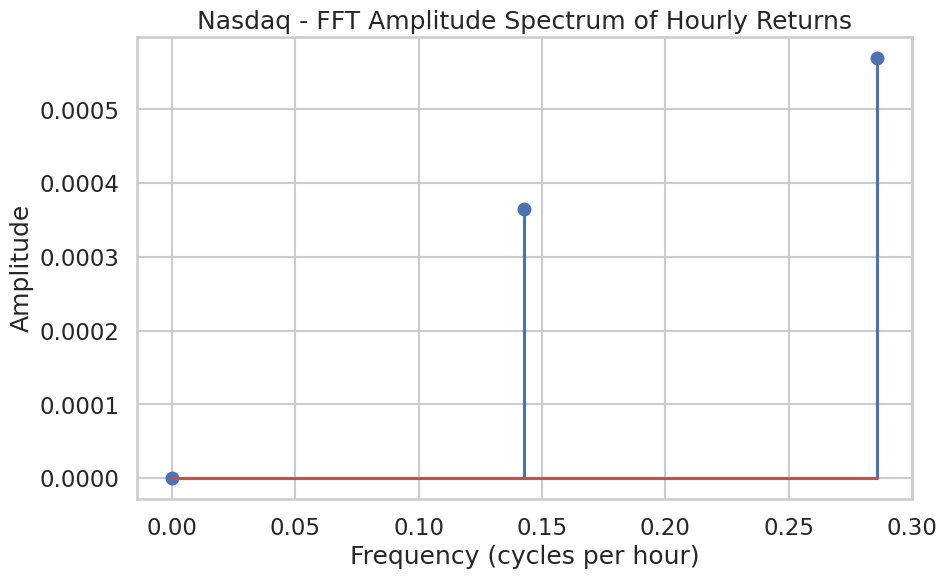

2025-02-13 01:38:01,551 - INFO - Downloading daily data for ^IXIC: period=5y
2025-02-13 01:38:01,938 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 01:38:01,948 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 01:38:02,136 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 01:38:02,147 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


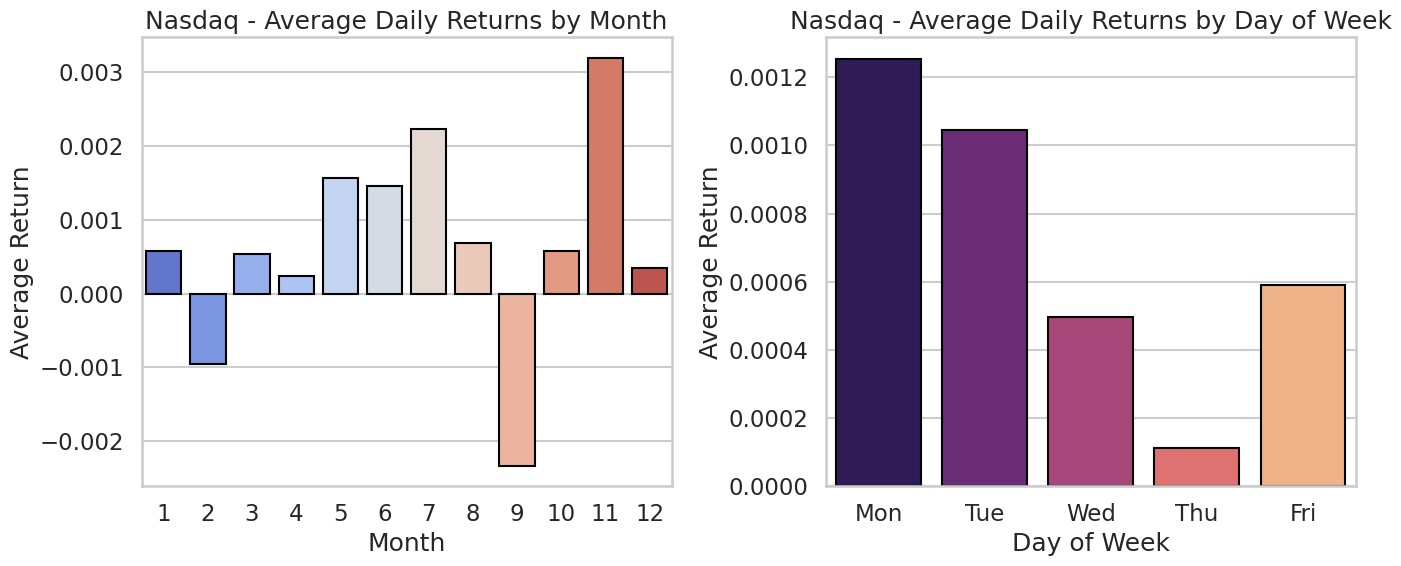

<Figure size 1200x800 with 0 Axes>

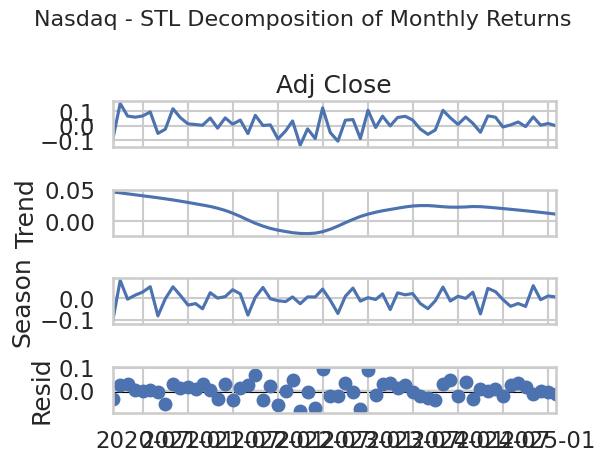

2025-02-13 01:38:04,377 - INFO - 
=== Processing S&P 500 (^GSPC) ===
2025-02-13 01:38:04,378 - INFO - Downloading intraday data for ^GSPC: period=1mo, interval=60m
2025-02-13 01:38:04,541 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 01:38:04,548 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 01:38:04,646 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.



Analysis Summary for Nasdaq
Intraday Hourly Analysis:
  • Best Hour: 9 (Avg Return: 0.16%)
  • Worst Hour: 10 (Avg Return: -0.04%)

Intraday Day-of-Week Analysis:
  • Best Day: Wednesday (Avg Return: 0.10%)
  • Worst Day: Monday (Avg Return: -0.08%)

Daily Seasonality Analysis:
  • Best Month: 11 (Avg Daily Return: 0.32%)
  • Worst Month: 9 (Avg Daily Return: -0.23%)
  • Best Day (Daily): Monday (Avg Return: 0.13%)
  • Worst Day (Daily): Thursday (Avg Return: 0.01%)

FFT Analysis:
  • Dominant frequency: 0.286 cycles per hour

    Nasdaq Seasonality Cheat Sheet:
      - **Intraday Patterns:** The best trading hour is around 9, while the worst is around 10. 
        The best intraday day is Wednesday, and the worst is Monday.
      - **Daily Patterns:** On a daily basis, month 11 tends to be most favorable, while month 9 is the least.
        Similarly, Monday shows the best daily performance, and Thursday the worst.
      - **Cyclical Behavior:** FFT analysis reveals a dominant cycle 

2025-02-13 01:38:04,656 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


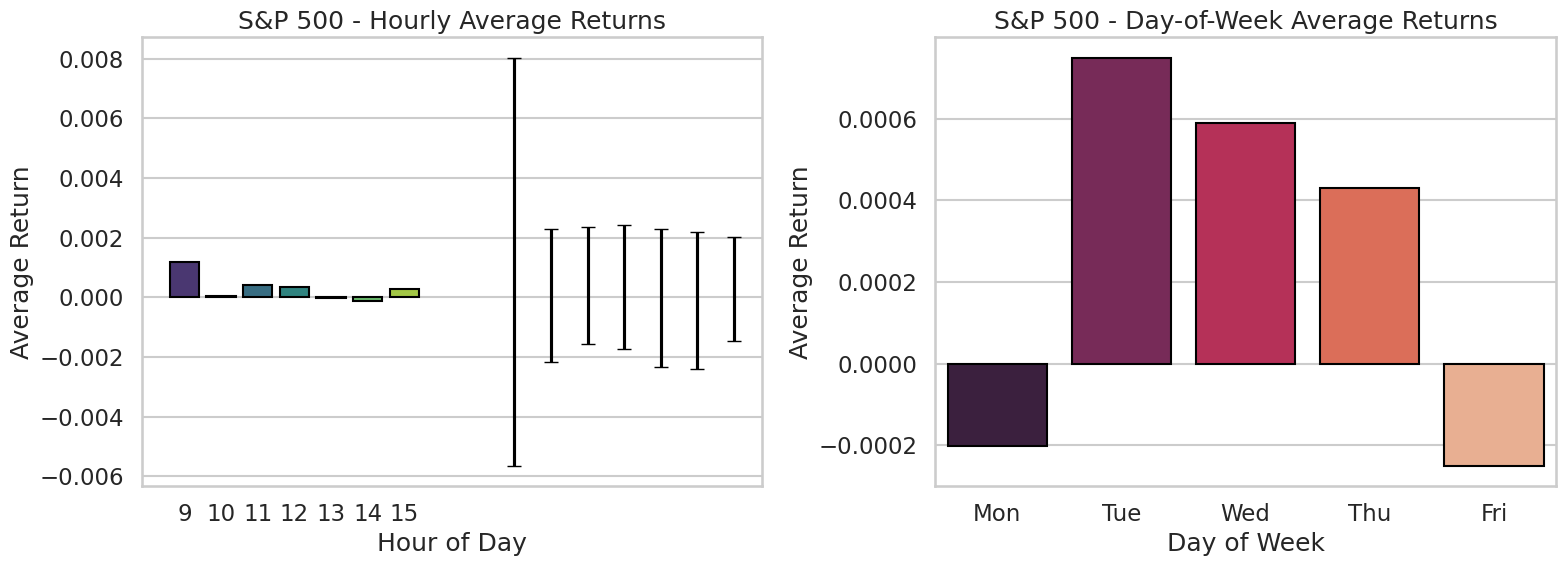

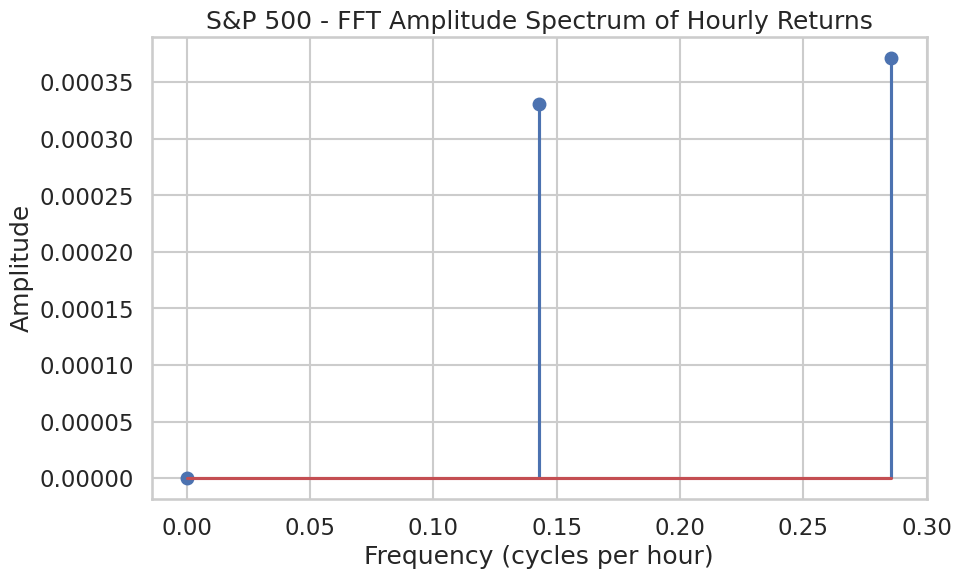

2025-02-13 01:38:05,411 - INFO - Downloading daily data for ^GSPC: period=5y
2025-02-13 01:38:05,638 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 01:38:05,646 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 01:38:05,769 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 01:38:05,776 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


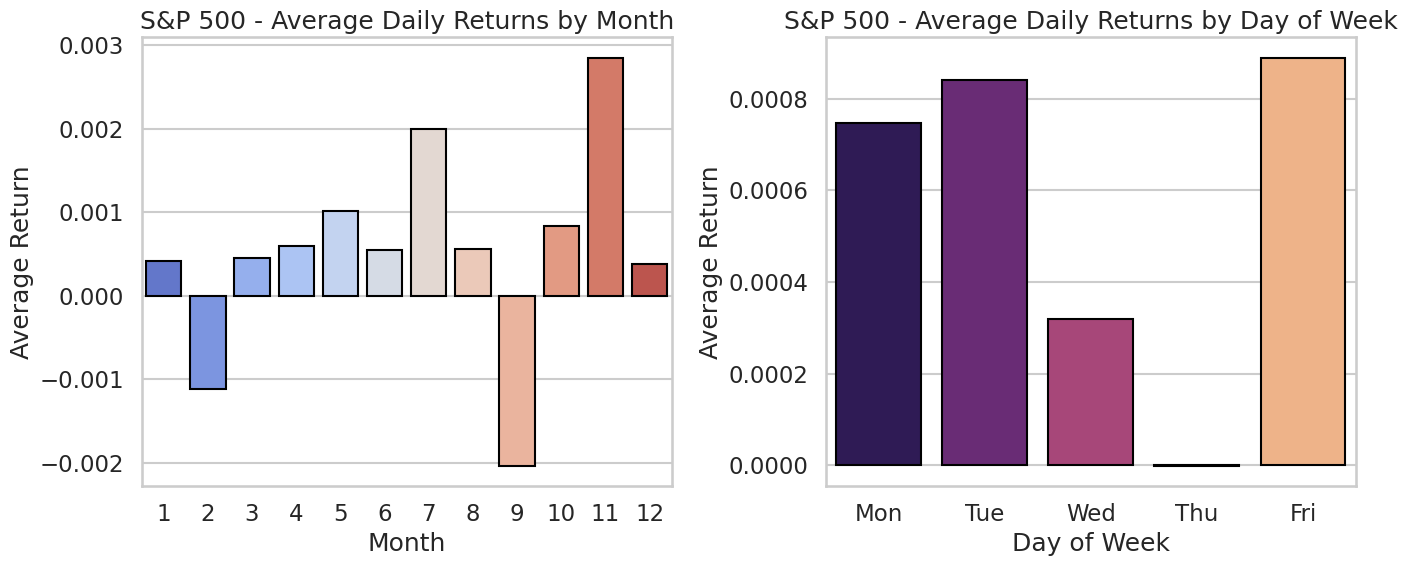

<Figure size 1200x800 with 0 Axes>

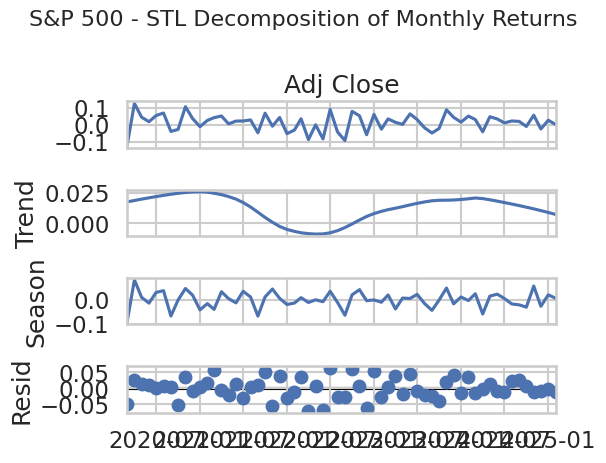

2025-02-13 01:38:08,087 - INFO - 
=== Processing Gold (GC=F) ===
2025-02-13 01:38:08,087 - INFO - Downloading intraday data for GC=F: period=1mo, interval=60m
2025-02-13 01:38:08,270 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 01:38:08,278 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.



Analysis Summary for S&P 500
Intraday Hourly Analysis:
  • Best Hour: 9 (Avg Return: 0.12%)
  • Worst Hour: 14 (Avg Return: -0.01%)

Intraday Day-of-Week Analysis:
  • Best Day: Tuesday (Avg Return: 0.07%)
  • Worst Day: Friday (Avg Return: -0.03%)

Daily Seasonality Analysis:
  • Best Month: 11 (Avg Daily Return: 0.29%)
  • Worst Month: 9 (Avg Daily Return: -0.20%)
  • Best Day (Daily): Friday (Avg Return: 0.09%)
  • Worst Day (Daily): Thursday (Avg Return: -0.00%)

FFT Analysis:
  • Dominant frequency: 0.286 cycles per hour

    S&P 500 Seasonality Cheat Sheet:
      - **Intraday Patterns:** The best trading hour is around 9, while the worst is around 14. 
        The best intraday day is Tuesday, and the worst is Friday.
      - **Daily Patterns:** On a daily basis, month 11 tends to be most favorable, while month 9 is the least.
        Similarly, Friday shows the best daily performance, and Thursday the worst.
      - **Cyclical Behavior:** FFT analysis reveals a dominant cycle o

2025-02-13 01:38:08,472 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 01:38:08,486 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


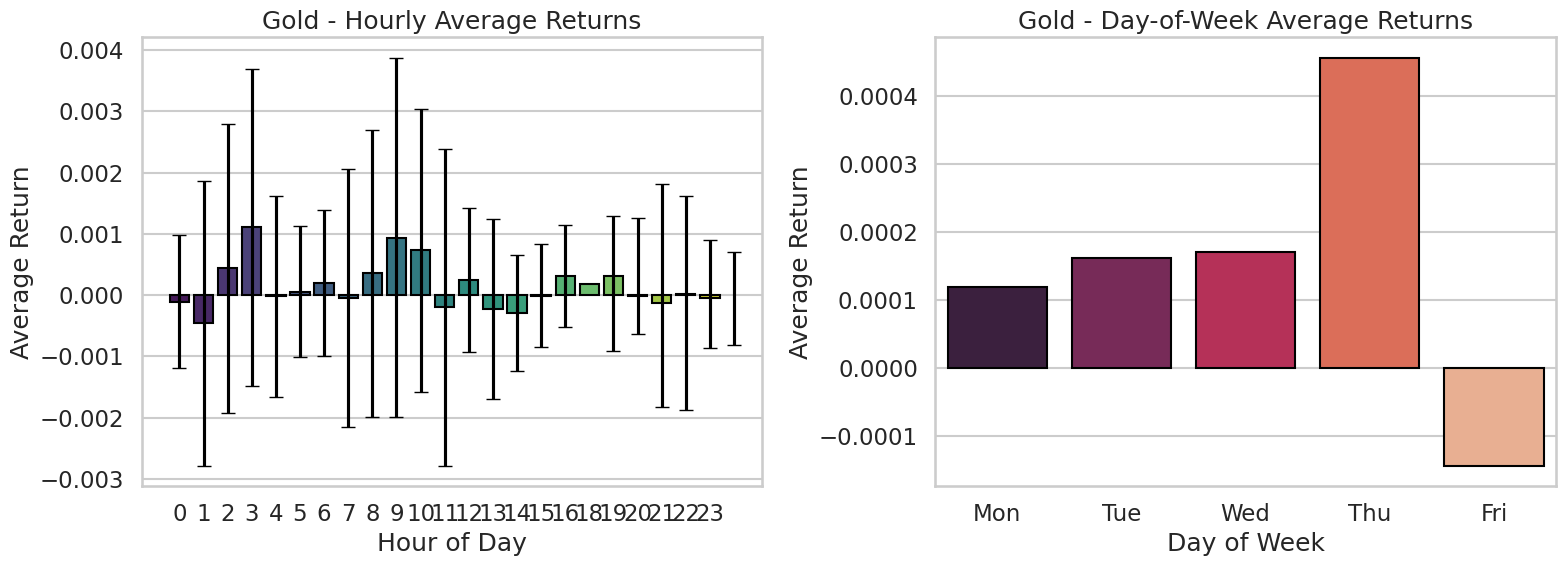

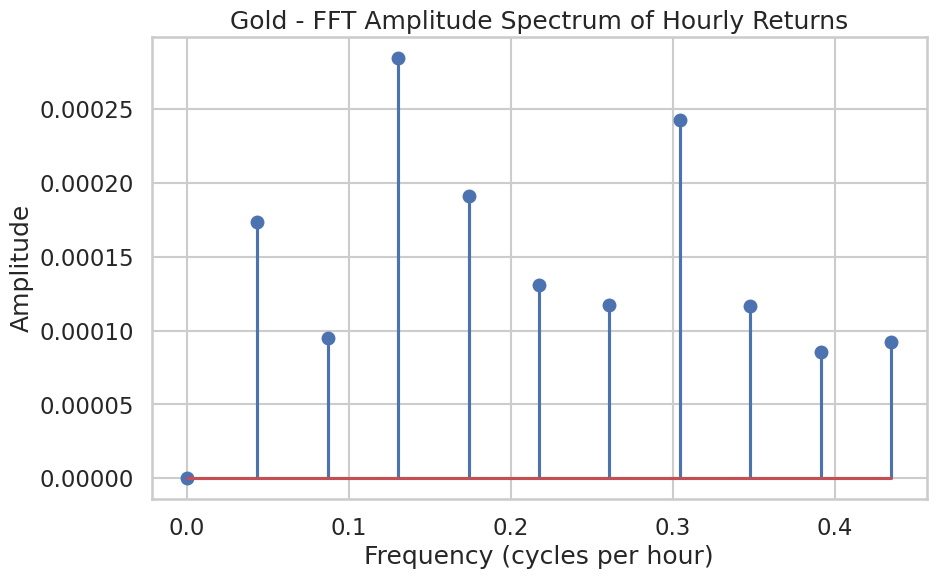

2025-02-13 01:38:09,168 - INFO - Downloading daily data for GC=F: period=5y
2025-02-13 01:38:09,346 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 01:38:09,353 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 01:38:09,512 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 01:38:09,519 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


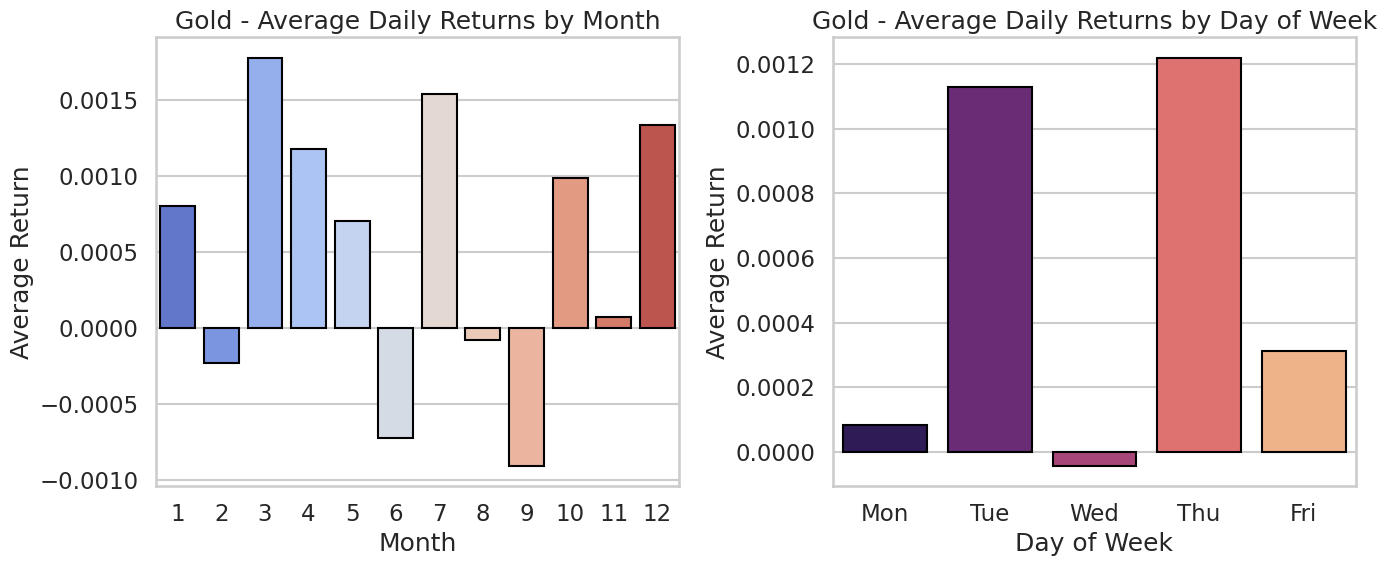

<Figure size 1200x800 with 0 Axes>

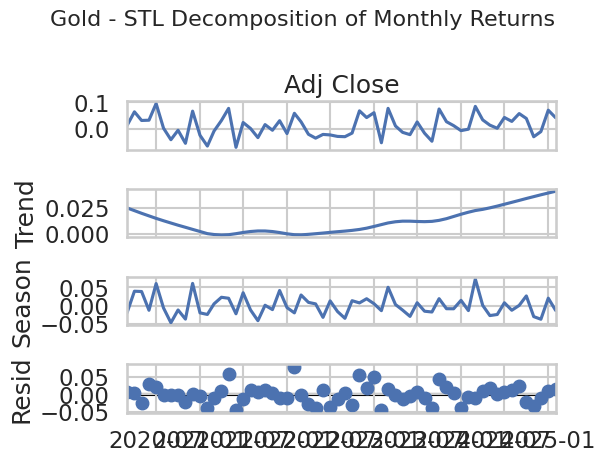

2025-02-13 01:38:11,499 - INFO - 
=== Processing Silver (SI=F) ===
2025-02-13 01:38:11,500 - INFO - Downloading intraday data for SI=F: period=1mo, interval=60m



Analysis Summary for Gold
Intraday Hourly Analysis:
  • Best Hour: 3 (Avg Return: 0.11%)
  • Worst Hour: 1 (Avg Return: -0.05%)

Intraday Day-of-Week Analysis:
  • Best Day: Thursday (Avg Return: 0.05%)
  • Worst Day: Sunday (Avg Return: -0.02%)

Daily Seasonality Analysis:
  • Best Month: 3 (Avg Daily Return: 0.18%)
  • Worst Month: 9 (Avg Daily Return: -0.09%)
  • Best Day (Daily): Thursday (Avg Return: 0.12%)
  • Worst Day (Daily): Wednesday (Avg Return: -0.00%)

FFT Analysis:
  • Dominant frequency: 0.130 cycles per hour

    Gold Seasonality Cheat Sheet:
      - **Intraday Patterns:** The best trading hour is around 3, while the worst is around 1. 
        The best intraday day is Thursday, and the worst is Sunday.
      - **Daily Patterns:** On a daily basis, month 3 tends to be most favorable, while month 9 is the least.
        Similarly, Thursday shows the best daily performance, and Wednesday the worst.
      - **Cyclical Behavior:** FFT analysis reveals a dominant cycle of 

2025-02-13 01:38:11,827 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 01:38:11,834 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 01:38:12,048 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 01:38:12,056 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


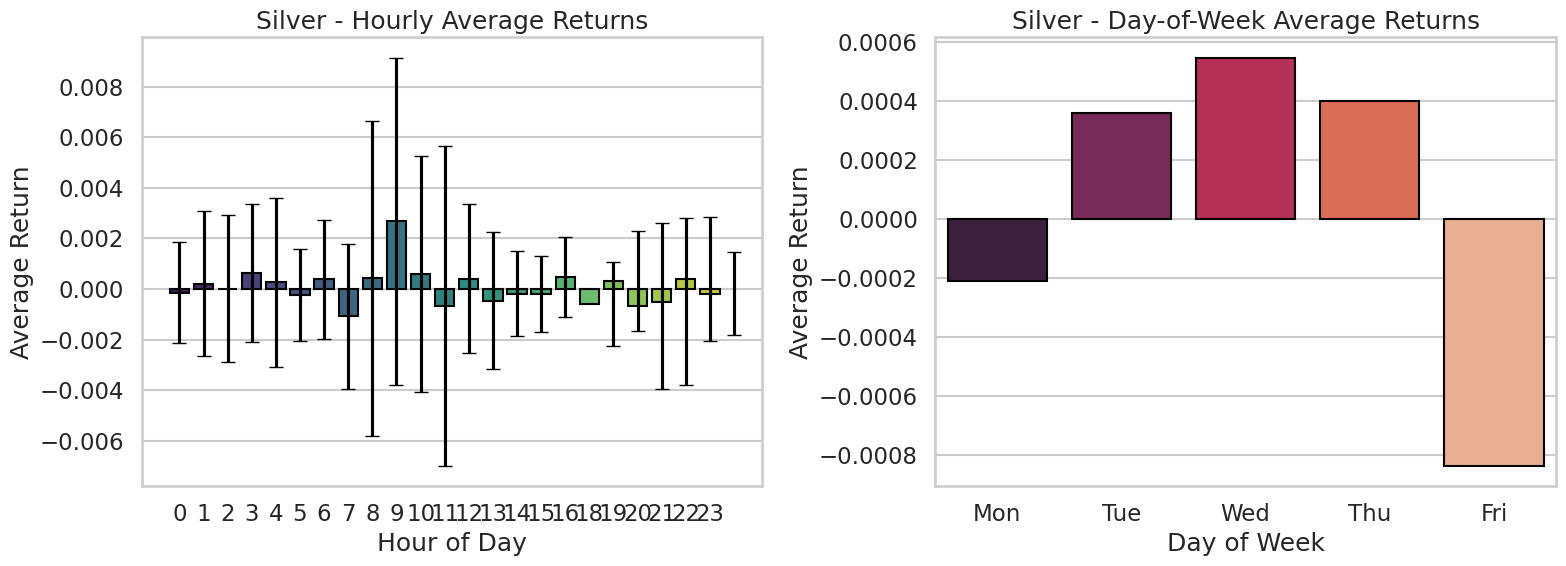

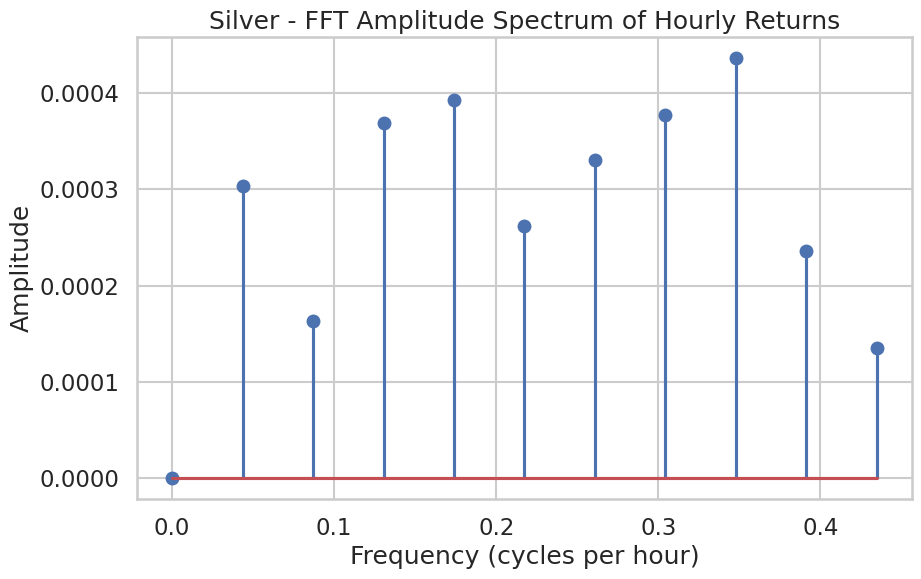

2025-02-13 01:38:12,823 - INFO - Downloading daily data for SI=F: period=5y
2025-02-13 01:38:13,008 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 01:38:13,016 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 01:38:13,152 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 01:38:13,160 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


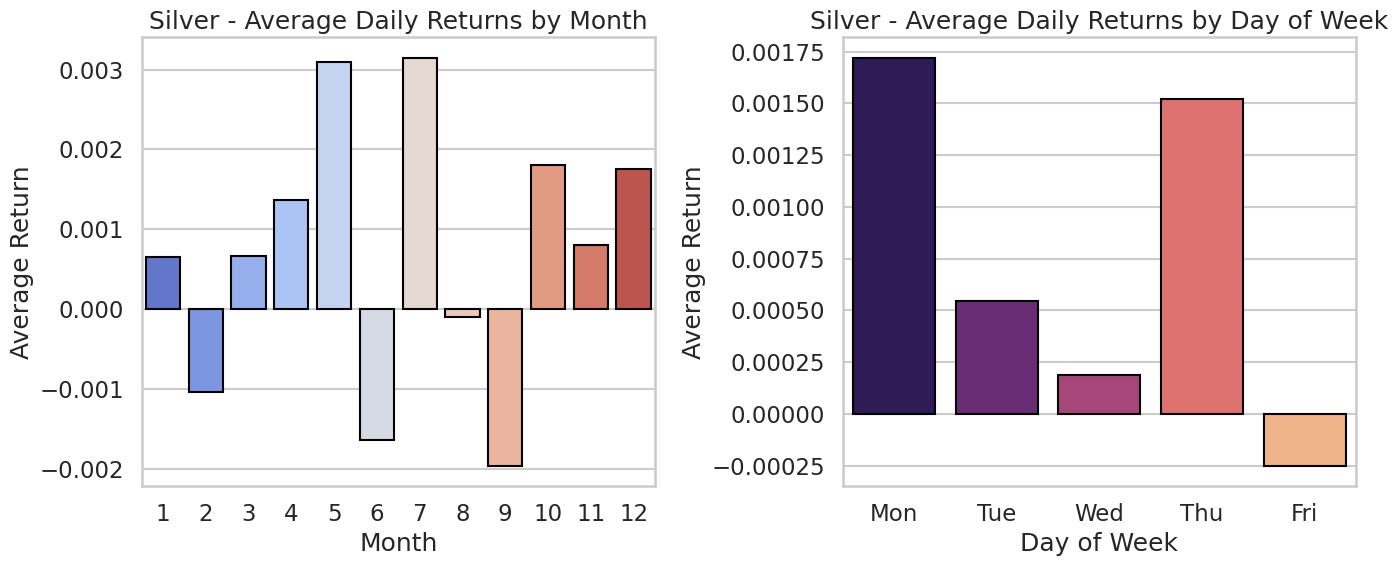

<Figure size 1200x800 with 0 Axes>

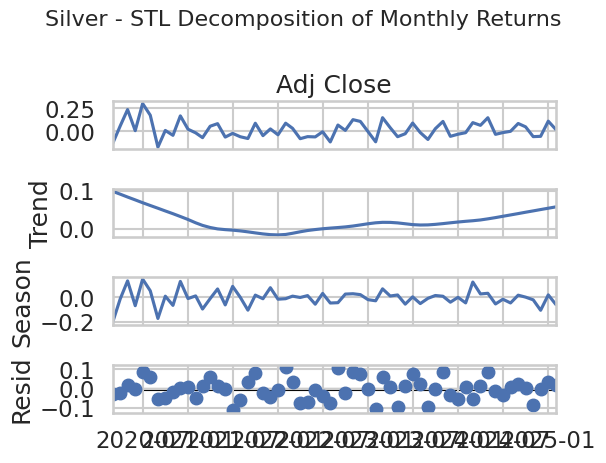

2025-02-13 01:38:15,290 - INFO - 
=== Processing Brent Crude (BZ=F) ===
2025-02-13 01:38:15,291 - INFO - Downloading intraday data for BZ=F: period=1mo, interval=60m



Analysis Summary for Silver
Intraday Hourly Analysis:
  • Best Hour: 9 (Avg Return: 0.27%)
  • Worst Hour: 7 (Avg Return: -0.11%)

Intraday Day-of-Week Analysis:
  • Best Day: Wednesday (Avg Return: 0.05%)
  • Worst Day: Friday (Avg Return: -0.08%)

Daily Seasonality Analysis:
  • Best Month: 7 (Avg Daily Return: 0.31%)
  • Worst Month: 9 (Avg Daily Return: -0.20%)
  • Best Day (Daily): Monday (Avg Return: 0.17%)
  • Worst Day (Daily): Friday (Avg Return: -0.03%)

FFT Analysis:
  • Dominant frequency: 0.348 cycles per hour

    Silver Seasonality Cheat Sheet:
      - **Intraday Patterns:** The best trading hour is around 9, while the worst is around 7. 
        The best intraday day is Wednesday, and the worst is Friday.
      - **Daily Patterns:** On a daily basis, month 7 tends to be most favorable, while month 9 is the least.
        Similarly, Monday shows the best daily performance, and Friday the worst.
      - **Cyclical Behavior:** FFT analysis reveals a dominant cycle of 0.34

2025-02-13 01:38:15,498 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 01:38:15,692 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 01:38:15,935 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 01:38:15,944 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


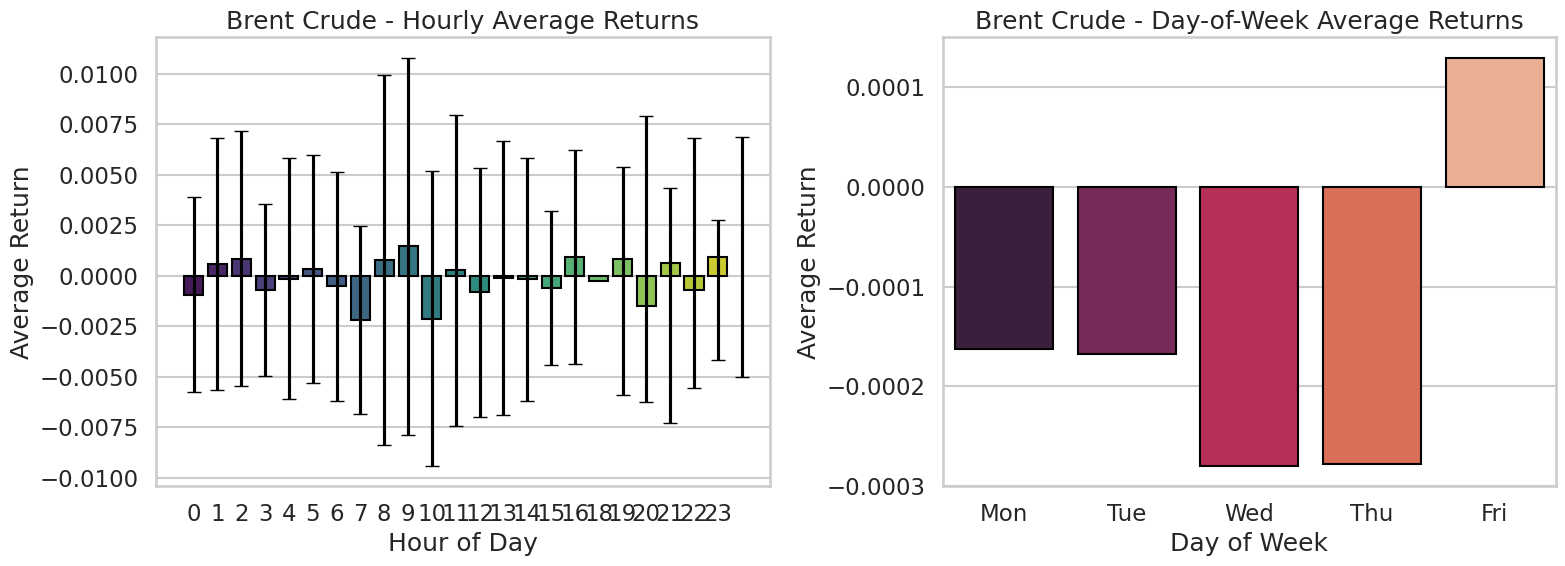

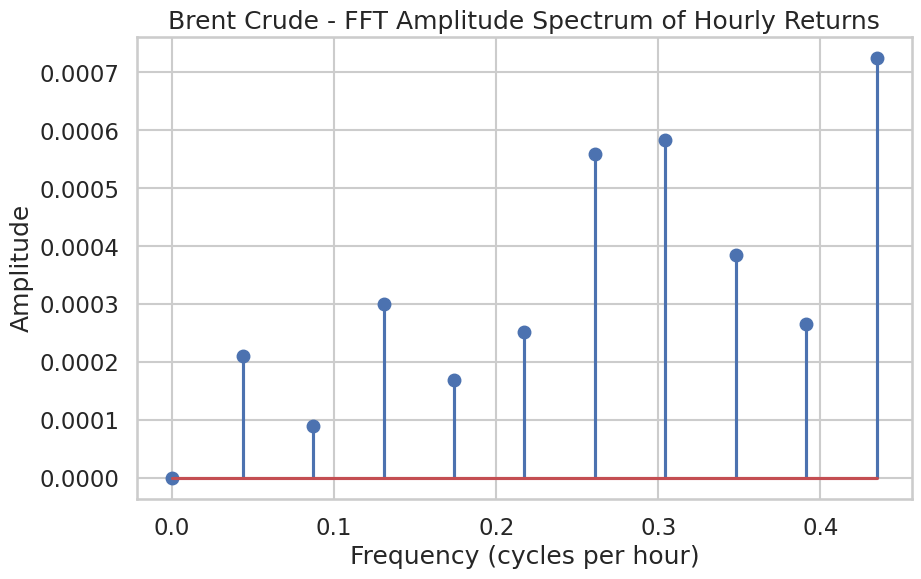

2025-02-13 01:38:16,747 - INFO - Downloading daily data for BZ=F: period=5y
2025-02-13 01:38:16,925 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 01:38:16,934 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 01:38:17,068 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 01:38:17,075 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


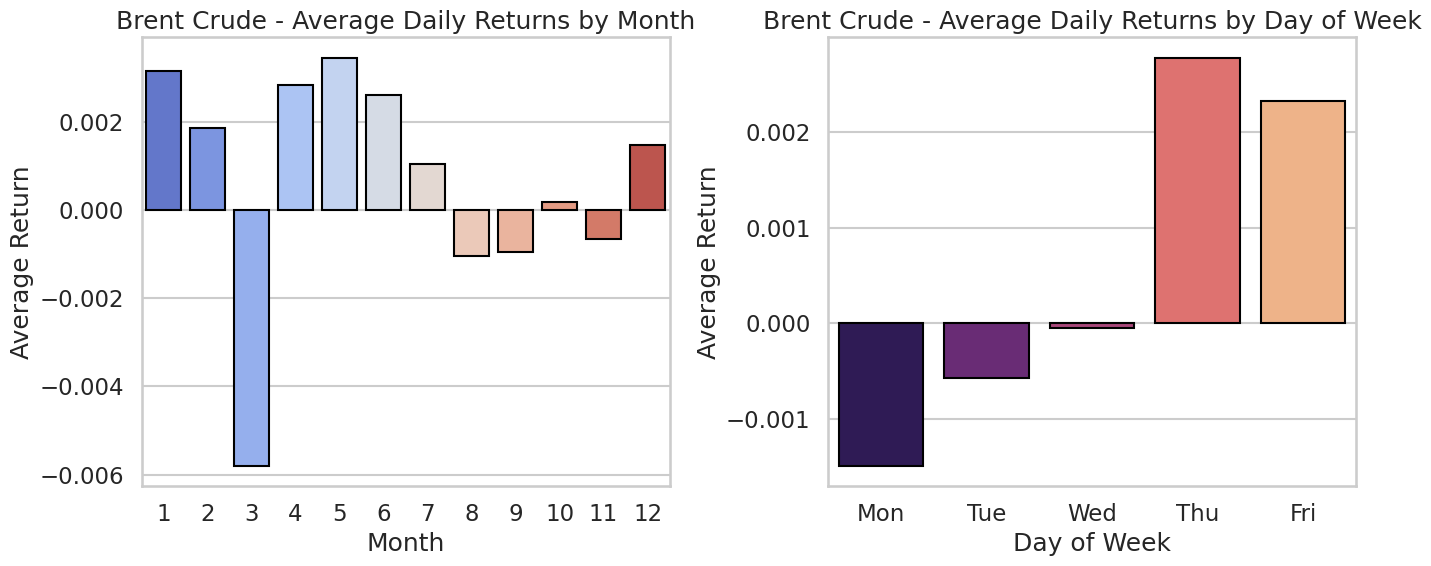

<Figure size 1200x800 with 0 Axes>

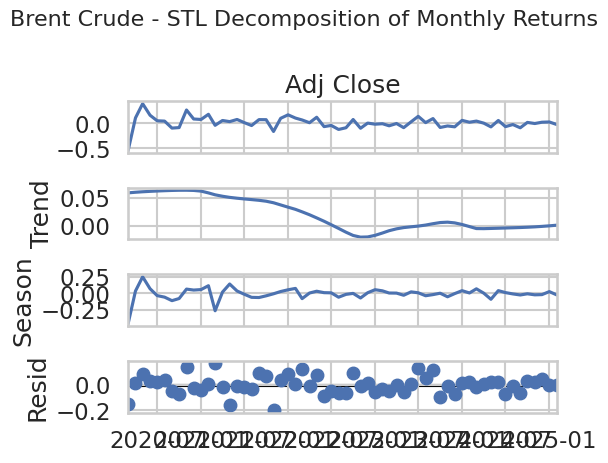

2025-02-13 01:38:19,130 - INFO - 
=== Processing DAX (^GDAXI) ===
2025-02-13 01:38:19,131 - INFO - Downloading intraday data for ^GDAXI: period=1mo, interval=60m
2025-02-13 01:38:19,297 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 01:38:19,305 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.



Analysis Summary for Brent Crude
Intraday Hourly Analysis:
  • Best Hour: 9 (Avg Return: 0.14%)
  • Worst Hour: 7 (Avg Return: -0.22%)

Intraday Day-of-Week Analysis:
  • Best Day: Sunday (Avg Return: 0.04%)
  • Worst Day: Wednesday (Avg Return: -0.03%)

Daily Seasonality Analysis:
  • Best Month: 5 (Avg Daily Return: 0.35%)
  • Worst Month: 3 (Avg Daily Return: -0.58%)
  • Best Day (Daily): Thursday (Avg Return: 0.28%)
  • Worst Day (Daily): Monday (Avg Return: -0.15%)

FFT Analysis:
  • Dominant frequency: 0.435 cycles per hour

    Brent Crude Seasonality Cheat Sheet:
      - **Intraday Patterns:** The best trading hour is around 9, while the worst is around 7. 
        The best intraday day is Sunday, and the worst is Wednesday.
      - **Daily Patterns:** On a daily basis, month 5 tends to be most favorable, while month 3 is the least.
        Similarly, Thursday shows the best daily performance, and Monday the worst.
      - **Cyclical Behavior:** FFT analysis reveals a dominant

2025-02-13 01:38:19,428 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 01:38:19,437 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


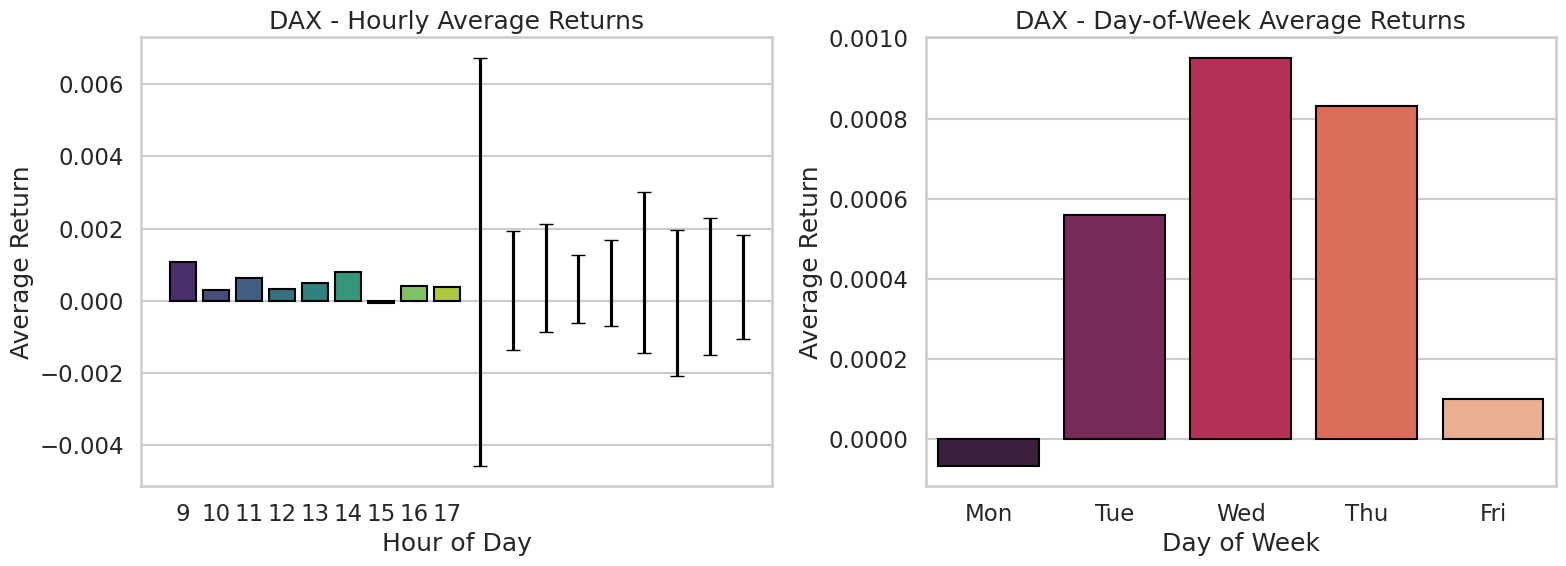

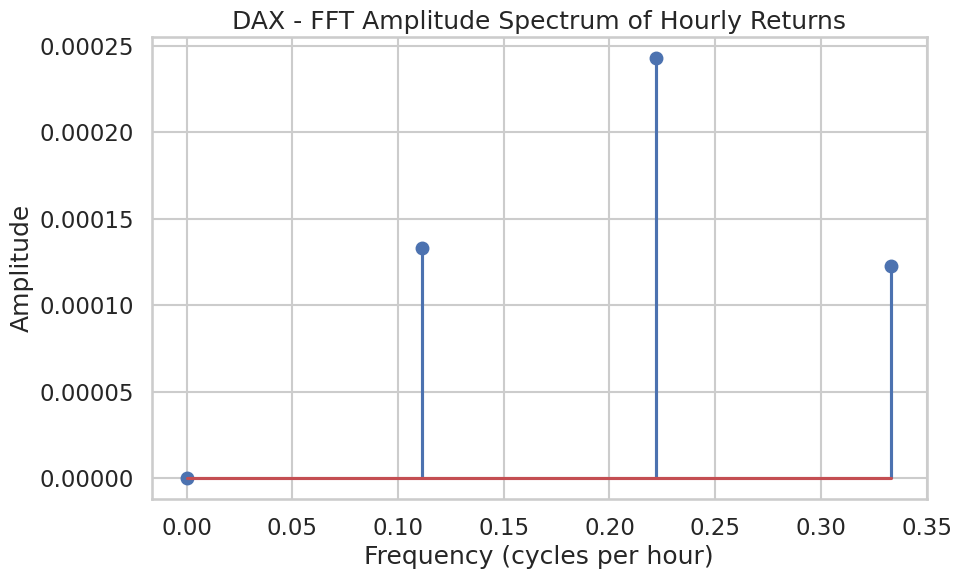

2025-02-13 01:38:20,271 - INFO - Downloading daily data for ^GDAXI: period=5y
2025-02-13 01:38:20,499 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 01:38:20,509 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 01:38:20,705 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-13 01:38:20,715 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


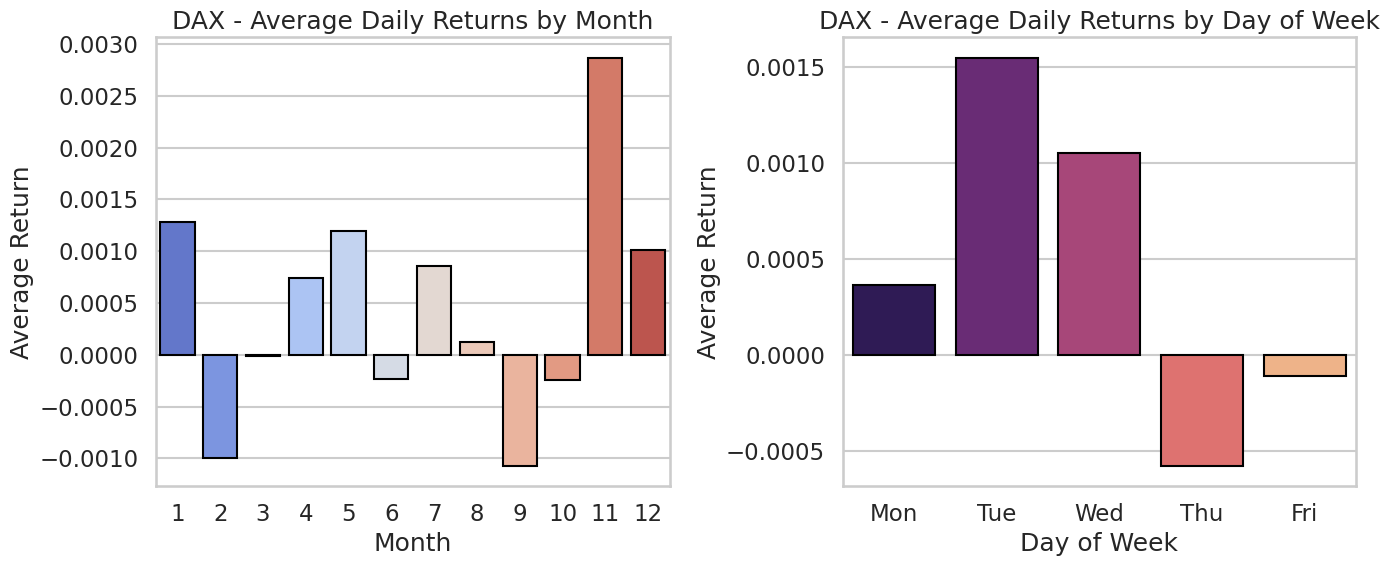

<Figure size 1200x800 with 0 Axes>

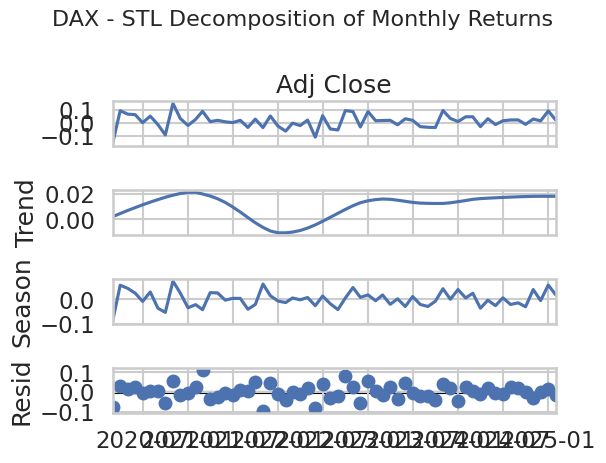


Analysis Summary for DAX
Intraday Hourly Analysis:
  • Best Hour: 9 (Avg Return: 0.11%)
  • Worst Hour: 15 (Avg Return: -0.01%)

Intraday Day-of-Week Analysis:
  • Best Day: Wednesday (Avg Return: 0.10%)
  • Worst Day: Monday (Avg Return: -0.01%)

Daily Seasonality Analysis:
  • Best Month: 11 (Avg Daily Return: 0.29%)
  • Worst Month: 9 (Avg Daily Return: -0.11%)
  • Best Day (Daily): Tuesday (Avg Return: 0.15%)
  • Worst Day (Daily): Thursday (Avg Return: -0.06%)

FFT Analysis:
  • Dominant frequency: 0.222 cycles per hour

    DAX Seasonality Cheat Sheet:
      - **Intraday Patterns:** The best trading hour is around 9, while the worst is around 15. 
        The best intraday day is Wednesday, and the worst is Monday.
      - **Daily Patterns:** On a daily basis, month 11 tends to be most favorable, while month 9 is the least.
        Similarly, Tuesday shows the best daily performance, and Thursday the worst.
      - **Cyclical Behavior:** FFT analysis reveals a dominant cycle of 

In [24]:
# %%
assets = {
    'Dow Jones': '^DJI',
    'Nasdaq': '^IXIC',
    'S&P 500': '^GSPC',
    'Gold': 'GC=F',
    'Silver': 'SI=F',
    'Brent Crude': 'BZ=F',
    'DAX': '^GDAXI'
}

for asset_name, ticker in assets.items():
    logging.info(f"\n=== Processing {asset_name} ({ticker}) ===")
    
    # ------------------------------
    # Intraday Analysis (1mo, 60m)
    df_intraday_raw = download_intraday_data(ticker, period="1mo", interval="60m")
    if df_intraday_raw.empty:
        continue
    df_intraday = compute_intraday_returns(df_intraday_raw)
    
    # Compute advanced intraday stats
    hourly_stats, dow_intraday = advanced_intraday_stats(df_intraday)
    # Plot intraday patterns
    plot_intraday_patterns(hourly_stats, dow_intraday, asset_name)
    # Perform FFT analysis on intraday hourly returns
    # Aggregate hourly series for FFT:
    hourly_series = df_intraday.groupby(df_intraday.index.hour)['Return'].mean()
    N = len(hourly_series)
    fft_vals = fft(hourly_series - hourly_series.mean())
    fft_amp = 2.0/N * np.abs(fft_vals[:N//2])
    fft_freqs = fftfreq(N, d=1)[:N//2]
    fft_analysis(df_intraday, asset_name)
    
    # ------------------------------
    # Daily Seasonality Analysis (5y daily data)
    df_daily_raw = download_daily_data(ticker, period="5y")
    if df_daily_raw.empty:
        continue
    df_daily = compute_daily_returns(df_daily_raw)
    monthly_stats, dow_daily = daily_seasonality_stats(df_daily)
    plot_daily_seasonality(monthly_stats, dow_daily, asset_name)
    stl_decomposition(df_daily, asset_name)
    
    # ------------------------------
    # Print comprehensive summary for the asset
    explain_results(asset_name, hourly_stats, dow_intraday, monthly_stats, dow_daily, fft_freqs, fft_amp)

## Conclusion

This notebook provided an advanced (“god‑mod”) seasonality analysis for multiple assets by integrating:

- **Intraday analysis:** Detailed hourly and day‑of‑week patterns, FFT for cyclical detection.
- **Daily analysis:** Seasonal decomposition, monthly and weekday patterns.

Use these insights as a dynamic cheat sheet to help time your day‑trades, optimize entries/exits, and refine your overall trading strategy.
